Extract NOAA CPD2 tarballs and save data to parquet files.
Provide plotting functions for data visualization.
Evaluate manual zero and span checks of nephelometer from October 2023.

joerg.klausen@meteoswiss.ch

In [3]:
import os
import polars as pl
from dataprocessor.cpd2 import CPD2

cpd2 = CPD2()

CPD2 initialized.


In [ ]:
# process CPD2 data files
years = ["2023"]
for year in years:
    source = os.path.join("/product_data/data/pay/Kenya/MKN/incoming/aerosol", year)
    target = os.path.join("results", "aerosol", year)
    errors = cpd2.tarballs_to_parquet(source=source, target=target, plot=False)
    print(errors)
print("done")

/home/zue/users/jkl/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


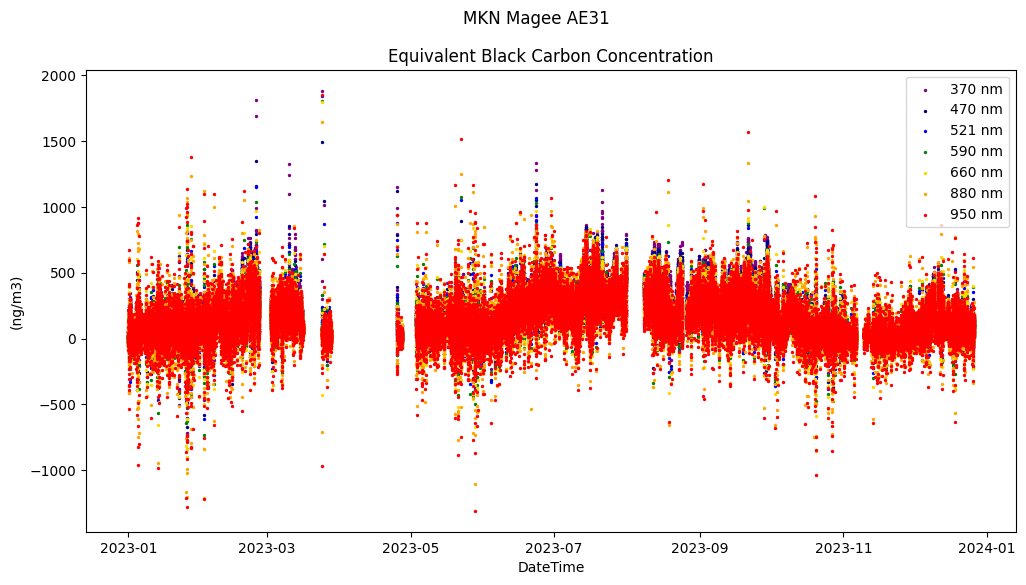

In [4]:
df = pl.read_parquet("/home/zue/users/jkl/Public/git/gawkenya/results/aerosol/2023/A11a.parquet")

cpd2.plot_aethalometer_data(df, variable="eBC")

In [ ]:
# # Concatenate the individual DataFrames into a single one
# combined_data = pl.concat(dataframes)

# # Assuming you have datetime columns, replace 'datetime_column' with the actual column name.
# datetime_column = 'timestamp'

# # Perform aggregation by datetime_column
# agg_data = (
#     combined_data
#     .with_column(combined_data[datetime_column].cast(pl.Date32))
#     .groupby(datetime_column)
#     .agg(pl.sum(combined_data['value_column']))
#     .sort(datetime_column)
# )